# Исследование линейной регрессии на наборе данных "Price of Used Toyota Corolla Cars"

Ссылка на датасет: https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

Импортируем все нужные библиотеки:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

Загружаем датасет:

In [2]:
df = pd.read_csv("ToyotaCorolla.csv", index_col="Id")

## 1) Первичный анализ данных (EDA) и предобработка

Смотрим на первые 5 строк набора данных:

In [3]:
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


Смотрим на последние 5 строк набора данных:

In [4]:
df.tail()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,Blue,...,1,1,0,1,1,1,0,0,0,0
1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,Grey,...,0,1,0,0,1,1,0,0,0,0
1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,Blue,...,0,1,0,0,0,1,0,0,0,0
1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,Grey,...,0,0,0,0,0,1,0,0,0,0
1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,76,5,1998,1,Petrol,110,0,Green,...,0,1,0,0,0,0,0,0,0,0


Смотрим размер датасета – количество строк и колонок:

In [5]:
df.shape

(1436, 38)

Выводим общую информацию о данных (количество ненулевых значений, тип):

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 1436 entries, 1 to 1442
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Model              1436 non-null   str  
 1   Price              1436 non-null   int64
 2   Age_08_04          1436 non-null   int64
 3   Mfg_Month          1436 non-null   int64
 4   Mfg_Year           1436 non-null   int64
 5   KM                 1436 non-null   int64
 6   Fuel_Type          1436 non-null   str  
 7   HP                 1436 non-null   int64
 8   Met_Color          1436 non-null   int64
 9   Color              1436 non-null   str  
 10  Automatic          1436 non-null   int64
 11  CC                 1436 non-null   int64
 12  Doors              1436 non-null   int64
 13  Cylinders          1436 non-null   int64
 14  Gears              1436 non-null   int64
 15  Quarterly_Tax      1436 non-null   int64
 16  Weight             1436 non-null   int64
 17  Mfr_Guarantee      1436 non-nu

Смотрим, сколько пропусков в каждой колонке:

In [7]:
df.isna().sum()

Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

Видим, что в нашем наборе данных отсутствуют пропуски.

Строим таблицу описательных статистик для числовых данных:

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1436.0,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.00,32500.0
Age_08_04,1436.0,55.947075,18.599988,1.0,44.0,61.0,70.00,80.0
Mfg_Month,1436.0,5.548747,3.354085,1.0,3.0,5.0,8.00,12.0
Mfg_Year,1436.0,1999.625348,1.540722,1998.0,1998.0,1999.0,2001.00,2004.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.0,110.0,110.00,192.0
Met_Color,1436.0,0.674791,0.468616,0.0,0.0,1.0,1.00,1.0
Automatic,1436.0,0.055710,0.229441,0.0,0.0,0.0,0.00,1.0
CC,1436.0,1576.855850,424.386770,1300.0,1400.0,1600.0,1600.00,16000.0
Doors,1436.0,4.033426,0.952677,2.0,3.0,4.0,5.00,5.0


Строим гистограмму для цен на авто:

<Axes: xlabel='Price', ylabel='Count'>

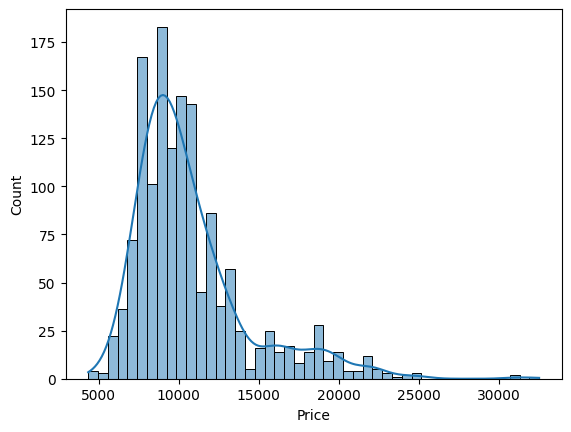

In [9]:
sns.histplot(df, x="Price", kde=True)

Распределение цен имеет выраженную **правостороннюю асимметрию**. На это указывает длинный хвост в сторону больших значений, что говорит о наличии небольшого числа значительно более дорогих автомобилей.

Построим также диаграмму размаха (он же ящик с усами):

<Axes: ylabel='Price'>

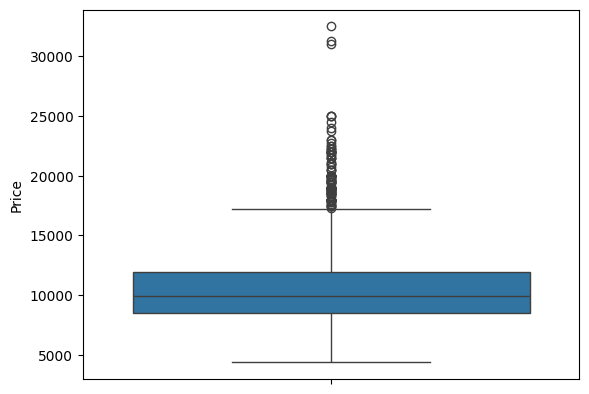

In [10]:
sns.boxplot(df.Price)

Видим точно такую же картину с присутствием очень больших цен на авто в наборе данных.

Теперь вычислим **корреляции** между признаками и построим тепловую карту:

<Axes: >

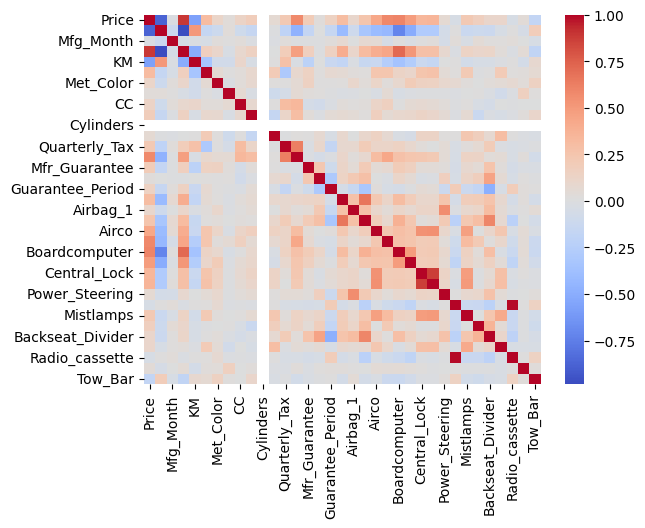

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

И определим, какие именно признаки наиболее сильно кореелируют с ценой на автомобиль:

In [12]:
target_corr = corr["Price"].sort_values(ascending=False)
target_corr.head(10)

Price              1.000000
Mfg_Year           0.885159
Boardcomputer      0.601292
Automatic_airco    0.588262
Weight             0.581198
CD_Player          0.481374
Airco              0.429259
Powered_Windows    0.356518
Central_Lock       0.343458
HP                 0.314990
Name: Price, dtype: float64

Далее посмотрим на распредление количества автомобилей с разными видами топлива:

<Axes: xlabel='Fuel_Type', ylabel='count'>

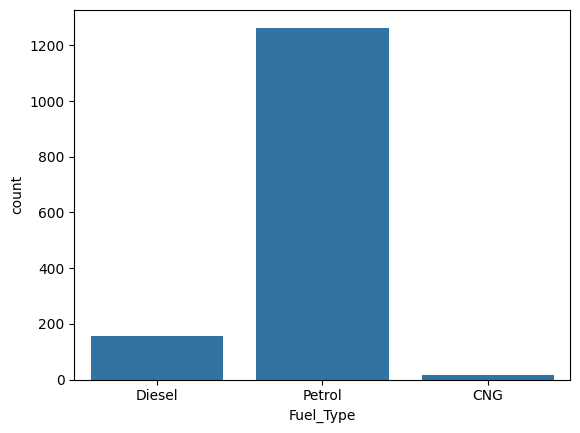

In [13]:
sns.countplot(data=df, x="Fuel_Type")

Машины на бензине явно выигрывают в нашем датасете!

Также нарисуем боксплоты для распределения цен на каждый тип топлива:

<Axes: xlabel='Fuel_Type', ylabel='Price'>

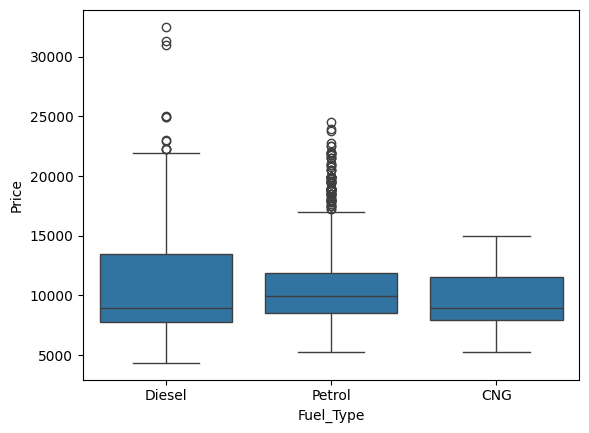

In [14]:
sns.boxplot(x="Fuel_Type", y="Price", data=df)

Можем заметить сильный разброс у цен на дизильные авто.

Далее проследим динамику цен на автомобиле по годам, дополнительно разбив по типу топлива:

<Axes: xlabel='Mfg_Year', ylabel='Price'>

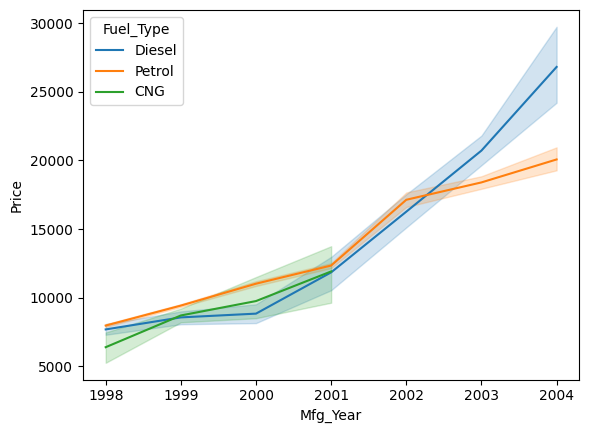

In [15]:
sns.lineplot(data=df, y="Price", x="Mfg_Year", hue="Fuel_Type")

Отметим стабильный рост цен автомобилей на бензине.

Посмотрим, какую зависимость имеет цена и километраж:

<Axes: xlabel='KM', ylabel='Price'>

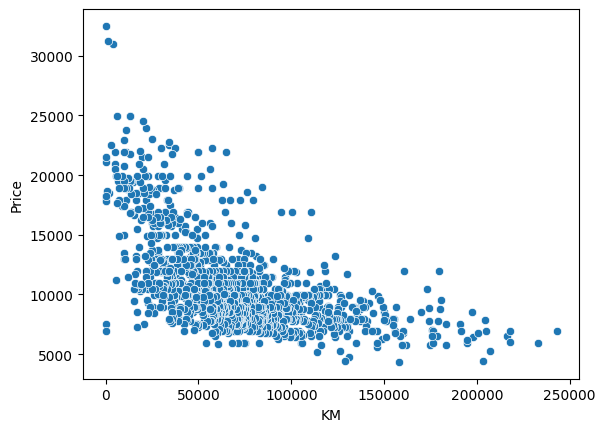

In [16]:
sns.scatterplot(x="KM", y="Price", data=df)

Наблюдаем линейную зависимость признаков.

Следующим шагом рассмотрим популярной разных цветов автомобилей в разные периоды продаж:

<Axes: xlabel='Mfg_Year', ylabel='count'>

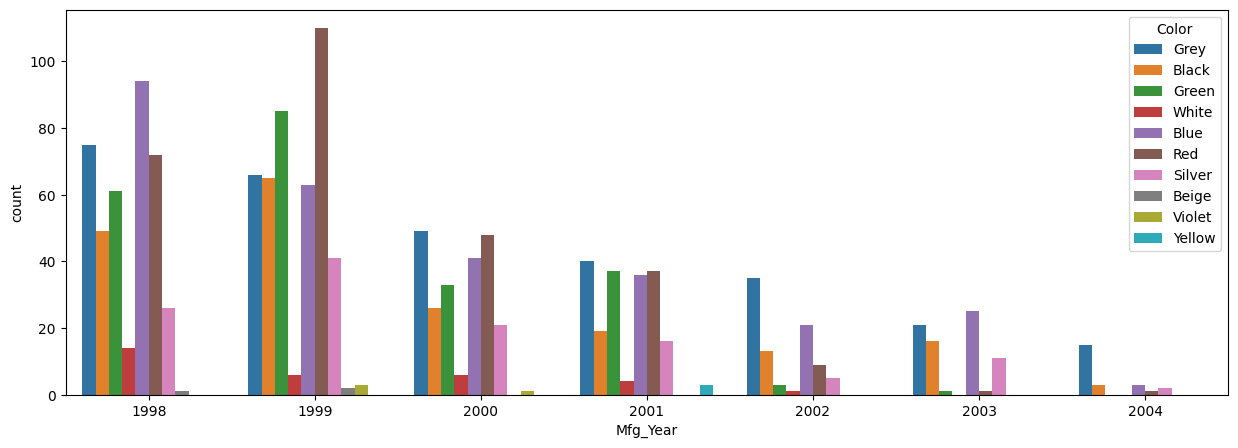

In [17]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="Mfg_Year", hue="Color")

Можно заметить, что серые тайоты всегда в тренде. А вот популярность красного цвета резко уменьшилась с началом 2000-х.

Также сделаем похожую диаграмму для видом топлива:

<Axes: xlabel='Mfg_Year', ylabel='count'>

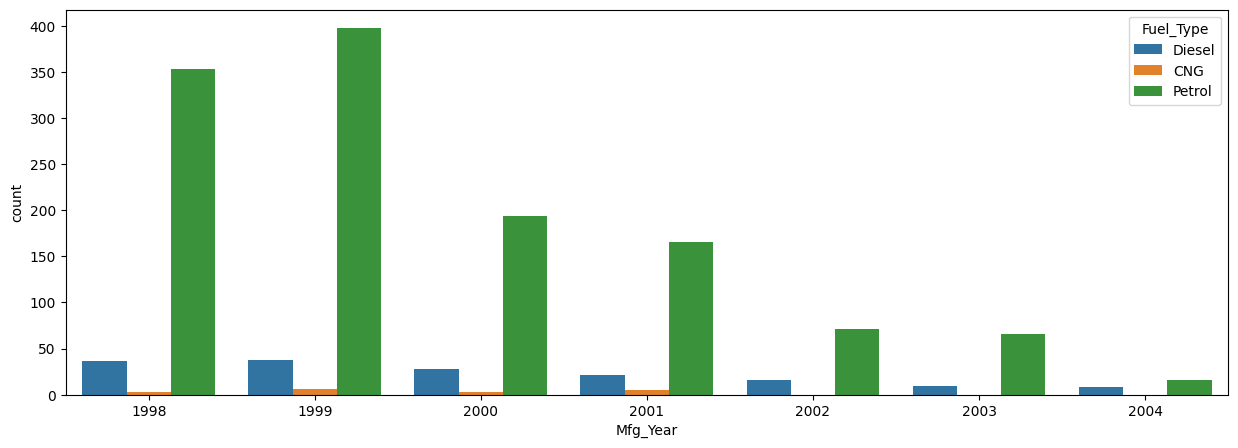

In [18]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="Mfg_Year", hue="Fuel_Type")

Бензин всегда опережал другие виды топлива конкретно для автомобилей Тайота.

### Какие выводы можно сделать из EDA?

Проведя разведочный анализ данных, были замечены несколько особенностей набора данных:

- Асимметрия распредления цен на автомобиле: довольно много значений выше среднего.

- Обнаружена заметная корреляция между ценой автомобиля и рядом признаков, включая год выпуска, массу автомобиля, а также наличие бортового компьютера.

- Также выявлена положительная динамика роста цен с увеличением года выпуска автомобиля. Дополнительно наблюдаются различия в ценовых тенденциях в зависимости от типа топлива.

Выявленные особенности данных следует учитывать при построении модели, в частности, правосторонняя асимметрия распределения цен может потребовать преобразования целевой переменной.

## 2) Работа с признаками *(Feature Engineering)*

Для начала удалим признаки, которые дублируют уже имеющиеся или просто не будут полезны при обучении модели. Таких в датасете три:

- **Model**: полное название модели, которое из себя представляет просто текст заголовка. Для задачи регрессии будет не слишком полезно

- **Mfg_Month**: месяц производства. При наличии колонки Age_08_04, где указан общий возраст авто, конкретный месяц будет не слишком полезен.

- **Mfg_Year**: год производства. По сути дублирует признак с возрастом автомобиля.

In [19]:
df_processed = df.drop(["Model", "Mfg_Month", "Mfg_Year"], axis=1).copy()
df_processed

,Price,Age_08_04,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,13500,23,46986,Diesel,90,1,Blue,0,2000,3,...,1,1,0,0,0,1,0,0,0,0
2,13750,23,72937,Diesel,90,1,Silver,0,2000,3,...,0,1,0,0,0,1,0,0,0,0
3,13950,24,41711,Diesel,90,1,Blue,0,2000,3,...,0,1,0,0,0,1,0,0,0,0
4,14950,26,48000,Diesel,90,0,Black,0,2000,3,...,0,1,0,0,0,1,0,0,0,0
5,13750,30,38500,Diesel,90,0,Black,0,2000,3,...,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,7500,69,20544,Petrol,86,1,Blue,0,1300,3,...,1,1,0,1,1,1,0,0,0,0
1439,10845,72,19000,Petrol,86,0,Grey,0,1300,3,...,0,1,0,0,1,1,0,0,0,0
1440,8500,71,17016,Petrol,86,0,Blue,0,1300,3,...,0,1,0,0,0,1,0,0,0,0


Далее узнаем, сколько уникальных значений имеют категориальные признаки для дальнейшего кодирования.

In [20]:
df_processed.Color.unique()

<StringArray>
[  'Blue', 'Silver',  'Black',  'White',   'Grey',    'Red',  'Green',
 'Yellow', 'Violet',  'Beige']
Length: 10, dtype: str

In [21]:
df_processed.Fuel_Type.unique()

<StringArray>
['Diesel', 'Petrol', 'CNG']
Length: 3, dtype: str

Так как признаки **Color** и **Fuel_Type** имеют довольно мало уникальных значений *(10 и 3 соответственно)*, можем воспользоваться встроенной функцией библиотеки Scikit-Learn для **One-hot кодирования** признаков:

In [22]:
from sklearn.preprocessing import OneHotEncoder

cat_columns = ["Fuel_Type", "Color"]

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = onehot_encoder.fit_transform(df_processed[cat_columns])
encoded_df = pd.DataFrame(encoded, columns=onehot_encoder.get_feature_names_out(cat_columns), index=df_processed.index)

df_processed = df_processed.drop(cat_columns, axis=1)
df_processed = pd.concat([df_processed, encoded_df], axis=1)

In [23]:
df_processed

,Price,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,...,Color_Beige,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
Id,,,,,,,,,,,,,,,,,,,,,
1,13500,23,46986,90,1,0,2000,3,4,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,13750,23,72937,90,1,0,2000,3,4,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13950,24,41711,90,1,0,2000,3,4,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14950,26,48000,90,0,0,2000,3,4,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13750,30,38500,90,0,0,2000,3,4,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,7500,69,20544,86,1,0,1300,3,4,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1439,10845,72,19000,86,0,0,1300,3,4,5,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1440,8500,71,17016,86,0,0,1300,3,4,5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3) Разделение выборки и нормализация данных

В качестве целевой переменной выбираем цену – колонку **Price**:

In [24]:
X = df_processed.drop("Price", axis=1)
y = df_processed.Price

Далее данные разделяются на обучающую и тестовую выборки. Это необходимо для объективной оценки качества модели на новых, ранее не виденных данных.
В данном случае используется разбиение в соотношении 75/25. Это значит, что модель обучается на 75% данных, выявляя закономерности, а затем её качество проверяется на оставшихся 25%.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

**1. Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели?**

Предобработка для случайного леса минимальна. Я не делал стандартизацию признаков, потому что случайный лес не чувствителен к масштабу. Деревья решений работают с порогами на основе значений признаков, и масштабирование никак не меняет их логику. Именно поэтому сдвиги и растяжения осей не влияют на то, какой признак выбран для разбиения и где проведена граница

**2. Как именно вы разделили выборку?**

Использовал `train_test_split` с соотношением 75% на обучение и 25% на тест, так же как и для линейной модели. Фиксировал `random_state=42` для воспроизводимости результатов.

**3. На сколько частей нужно делить выборку при использовании кросс-валидации?**

Обычно делят на 5 или 10 частей. 5-фолдовая кросс-валидация даёт хороший баланс между смещением и дисперсией оценки, 10-фолдовая точнее, но дольше. Для средних данных (несколько тысяч объектов) чаще используют 5 или 10

**4. Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?**

Можно. Без кросс-валидации выборка делится просто на обучающую и тестовую (например, 80/20 или 75/25). Модель обучается один раз на обучающей части, качество проверяется на тестовой. Минус — оценка зависит от того, как именно разбили данные. Кросс-валидация усредняет оценку по нескольким разбиениям, давая более стабильный результат.

## 4) Обучение моделей

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Обучаем одно **решающее дерево** с заданными параметрами:

In [31]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

Далее перейдём к **случайному лесу**. Обучим ансамбль на выбранных параметрах:

In [32]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

In [33]:
import time

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

times = {}
predictions = {}
metrics = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train) 
    end = time.time()
    times[name] = end - start
    
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    metrics[name] = {
        "R²": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    }

In [42]:
for name, t in times.items():
    print(f"{name}: {t:.4f} секунд")

comparison_df = pd.DataFrame({
    "Decision Tree": metrics["Decision Tree"],
    "Random Forest": metrics["Random Forest"]
})

comparison_df.round(4)

Decision Tree: 0.0389 секунд
Random Forest: 0.1892 секунд


,Decision Tree,Random Forest
R²,8.862000e-01,9.251000e-01
MSE,1.614245e+06,1.062802e+06
MAE,9.307081e+02,7.722015e+02


**1. Сравнение скорости: сравните, какая модель обучалась быстрее.**

Одно дерево обучалось быстрее — 0.039 секунды против 0.189 секунды у случайного леса. Лес медленнее примерно в 5 раз

**2. Можно ли добиться одинаковой или близкой к одинаковой скорости?**

Нельзя. Случайный лес по определению строит много деревьев, поэтому он всегда будет медленнее одного дерева. Единственный способ приблизить скорость — уменьшить количество деревьев до 10-20, но тогда пострадает качество. Можно ещё использовать параллелизацию (n_jobs=-1), но это ускоряет, но не сравнивает с одним деревом

**3. Сравнение качества: сравните результаты одного дерева и случайного леса.**

Случайный лес показывает лучшее качество по всем метрикам. R² вырос с 0.886 до 0.925. MSE снизилась на 34% (с 1.61 млн до 1.06 млн). MAE снизилась на 17% (с 931 до 772). Лес даёт более точные предсказания, потому что усредняет мнения многих деревьев и сглаживает их ошибки. Одно дерево больше подвержено шуму и выбросам в данных

## 5) Оценка качества и сравнение моделей


Для оценки качества и сравнения моделей для наглядности я решил использовать все основные метрики: *MAE, RMSE и R2*. Но стоит отметить, что конкретно для задачи предсказания цены на авто лучше подойдёт **абсолютная ошибка (MAE)**, так как она не так сильно зависима от выбросов и показывает среднюю ошибку в единицах измерения цен.

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Все метрики будем рассчитывать на **тестовой выборке**, которая не использовалась при обучении моделей.

In [59]:
y_lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_lr_pred))
lr_r2 = r2_score(y_test, y_lr_pred)

In [60]:
y_ridge_pred = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, y_ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_ridge_pred))
ridge_r2 = r2_score(y_test, y_ridge_pred)

In [61]:
y_lasso_pred = lasso_model.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, y_lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_lasso_pred))
lasso_r2 = r2_score(y_test, y_lasso_pred)

In [62]:
print("Base Linear regression:")
print(f"MAE: {lr_mae:.3f}")
print(f"RMSE: {lr_rmse:.3f}")
print(f"R2: {lr_r2:.4f}")

print("\nRidge Linear regression:")
print(f"MAE: {ridge_mae:.3f}")
print(f"RMSE: {ridge_rmse:.3f}")
print(f"R2: {ridge_r2:.4f}")

print("\nLasso Linear regression:")
print(f"MAE: {lasso_mae:.3f}")
print(f"RMSE: {lasso_rmse:.3f}")
print(f"R2: {lasso_r2:.4f}")

Base Linear regression:
MAE: 849.313
RMSE: 1211.460
R2: 0.8966

Ridge Linear regression:
MAE: 843.933
RMSE: 1195.595
R2: 0.8993

Lasso Linear regression:
MAE: 856.040
RMSE: 1210.866
R2: 0.8967


Лучше всего показал себя **случайный лес** — у него наименьшая ошибка и наибольший R² (0.925). Это ожидаемо, так как лес усредняет много деревьев и сглаживает их ошибки.

Линейные модели оказались в середине — Ridge с R² 0.899, обычная линейная регрессия и Lasso чуть хуже, около 0.896. Регуляризация не дала значительного улучшения, значит, с мультиколлинеарностью в данных всё нормально.

Хуже всех выступило одно дерево — R² всего 0.886, ошибки самые высокие. Оно сильно переобучается и чувствительно к шуму, поэтому проигрывает даже линейным моделям.